
1. ДОБАВЛЕНИЕ НОВОГО АТРИБУТА
Добавленные атрибуты:
- acidity_profile: соотношение фиксированной и летучей кислотности
- sweetness_category: категория сладости вина

Новые размеры датасета: (1599, 14)

2. ПРЕДОБРАБОТКА ДАННЫХ
Количество дубликатов: 240
Размер датасета после удаления дубликатов: (1359, 14)

ОБРАБОТКА ВЫБРОСОВ:
fixed acidity            :  41 выбросов
volatile acidity         :  19 выбросов
citric acid              :   1 выбросов
residual sugar           : 126 выбросов
chlorides                :  87 выбросов
free sulfur dioxide      :  26 выбросов
total sulfur dioxide     :  45 выбросов
density                  :  35 выбросов
pH                       :  28 выбросов
sulphates                :  55 выбросов
alcohol                  :  12 выбросов
quality                  :  27 выбросов
acidity_profile          :  44 выбросов

Размер датасета после удаления выбросов: (978, 14)
Удалено записей: 381

3. ВИЗУАЛИЗАЦИЯ ДАННЫХ И ПОИСК КЛАСТЕРОВ


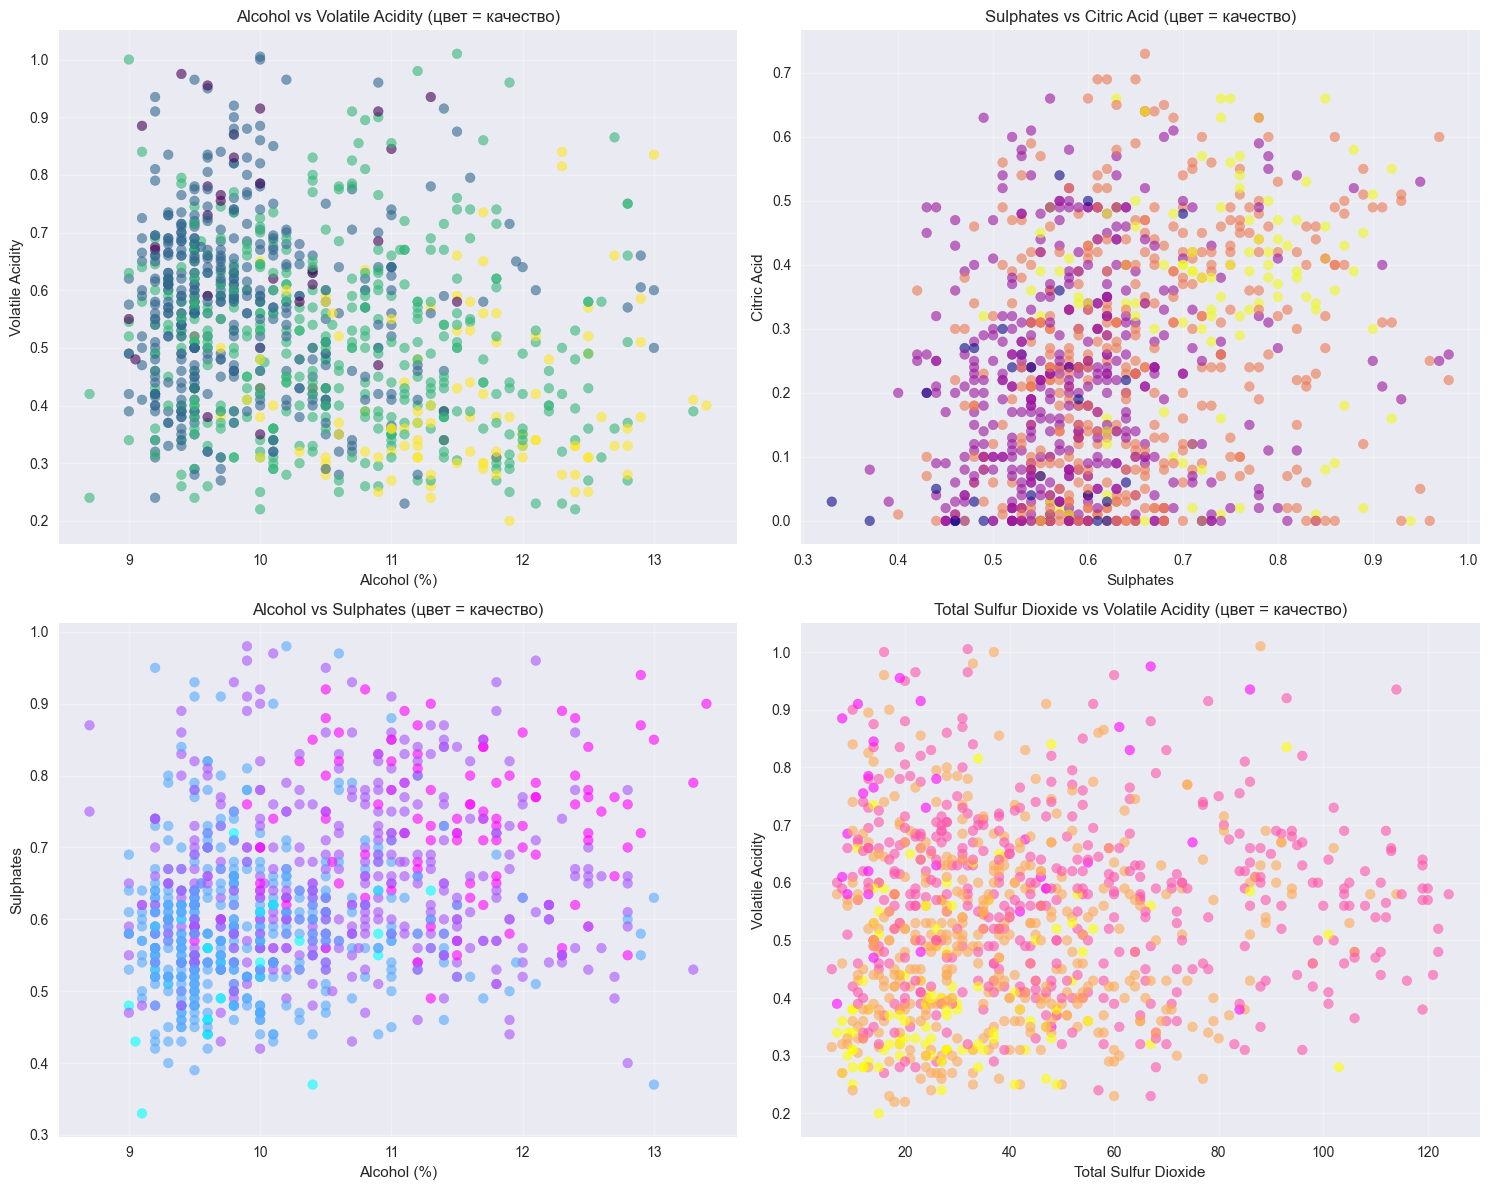

ВИЗУАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ:
• На графиках видны потенциальные кластеры, особенно в распределениях:
  - Alcohol vs Volatile Acidity: выделяются 2-3 группы
  - Alcohol vs Sulphates: заметны компактные группы
  - Total Sulfur Dioxide vs Volatile Acidity: видна сегментация


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

print("\n1. ДОБАВЛЕНИЕ НОВОГО АТРИБУТА")
print("="*50)

wine_data['acidity_profile'] = wine_data['fixed acidity'] / wine_data['volatile acidity']
wine_data['sweetness_category'] = pd.cut(wine_data['residual sugar'], 
                                       bins=[0, 4, 12, 20, 100],
                                       labels=['Сухое', 'Полусухое', 'Полусладкое', 'Сладкое'])

print("Добавленные атрибуты:")
print("- acidity_profile: соотношение фиксированной и летучей кислотности")
print("- sweetness_category: категория сладости вина")
print(f"\nНовые размеры датасета: {wine_data.shape}")

print("\n2. ПРЕДОБРАБОТКА ДАННЫХ")
print("="*50)

duplicates = wine_data.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")

wine_data_clean = wine_data.drop_duplicates()
print(f"Размер датасета после удаления дубликатов: {wine_data_clean.shape}")

print("\nОБРАБОТКА ВЫБРОСОВ:")

numeric_columns = wine_data_clean.select_dtypes(include=[np.number]).columns

outlier_mask = pd.Series([False] * len(wine_data_clean))

for column in numeric_columns:
    Q1 = wine_data_clean[column].quantile(0.25)
    Q3 = wine_data_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    column_outliers = (wine_data_clean[column] < lower_bound) | (wine_data_clean[column] > upper_bound)
    outlier_mask = outlier_mask | column_outliers
    
    outliers_count = column_outliers.sum()
    print(f"{column:25}: {outliers_count:3} выбросов")

wine_data_no_outliers = wine_data_clean[~outlier_mask].copy()

print(f"\nРазмер датасета после удаления выбросов: {wine_data_no_outliers.shape}")
print(f"Удалено записей: {len(wine_data_clean) - len(wine_data_no_outliers)}")

print("\n3. ВИЗУАЛИЗАЦИЯ ДАННЫХ И ПОИСК КЛАСТЕРОВ")
print("="*50)

features_for_clustering = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].scatter(wine_data_no_outliers['alcohol'], 
                 wine_data_no_outliers['volatile acidity'], 
                 alpha=0.6, c=wine_data_no_outliers['quality'], cmap='viridis')
axes[0,0].set_xlabel('Alcohol (%)')
axes[0,0].set_ylabel('Volatile Acidity')
axes[0,0].set_title('Alcohol vs Volatile Acidity (цвет = качество)')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].scatter(wine_data_no_outliers['sulphates'], 
                 wine_data_no_outliers['citric acid'], 
                 alpha=0.6, c=wine_data_no_outliers['quality'], cmap='plasma')
axes[0,1].set_xlabel('Sulphates')
axes[0,1].set_ylabel('Citric Acid')
axes[0,1].set_title('Sulphates vs Citric Acid (цвет = качество)')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(wine_data_no_outliers['alcohol'], 
                 wine_data_no_outliers['sulphates'], 
                 alpha=0.6, c=wine_data_no_outliers['quality'], cmap='cool')
axes[1,0].set_xlabel('Alcohol (%)')
axes[1,0].set_ylabel('Sulphates')
axes[1,0].set_title('Alcohol vs Sulphates (цвет = качество)')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(wine_data_no_outliers['total sulfur dioxide'], 
                 wine_data_no_outliers['volatile acidity'], 
                 alpha=0.6, c=wine_data_no_outliers['quality'], cmap='spring')
axes[1,1].set_xlabel('Total Sulfur Dioxide')
axes[1,1].set_ylabel('Volatile Acidity')
axes[1,1].set_title('Total Sulfur Dioxide vs Volatile Acidity (цвет = качество)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ВИЗУАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ:")
print("• На графиках видны потенциальные кластеры, особенно в распределениях:")
print("  - Alcohol vs Volatile Acidity: выделяются 2-3 группы")
print("  - Alcohol vs Sulphates: заметны компактные группы")
print("  - Total Sulfur Dioxide vs Volatile Acidity: видна сегментация")


4. КЛАСТЕРИЗАЦИЯ МЕТОДОМ K-MEANS
ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ:


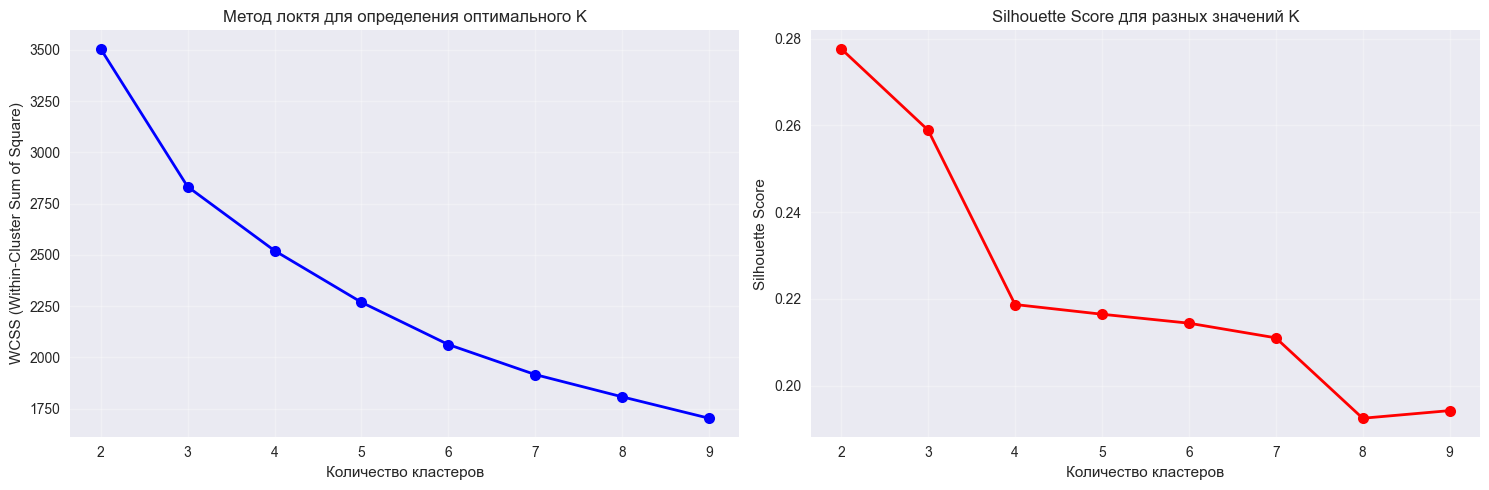

Оптимальное количество кластеров: 2

РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:
Кластер 0: 638 образцов (65.2%)
Кластер 1: 340 образцов (34.8%)

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ:


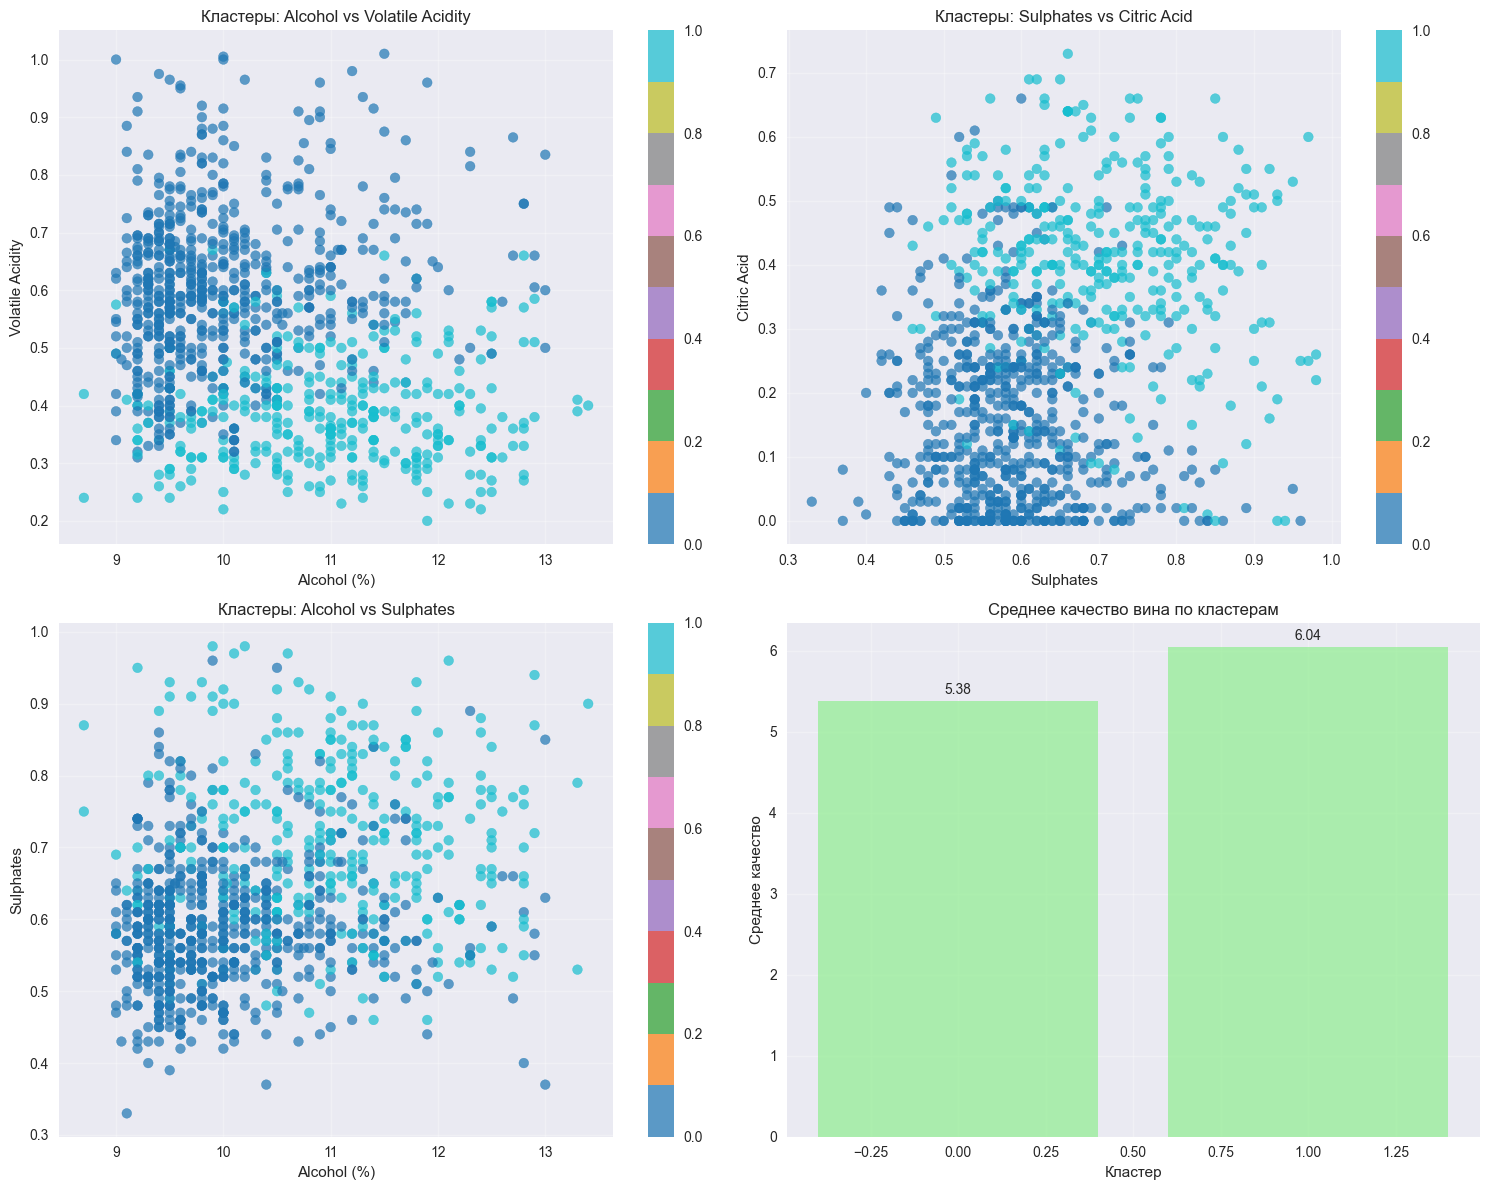


АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ:
СРЕДНИЕ ЗНАЧЕНИЯ ХАРАКТЕРИСТИК ПО КЛАСТЕРАМ:


,alcohol,volatile acidity,sulphates,citric acid,total sulfur dioxide,quality
cluster,,,,,,
0,10.025,0.607,0.586,0.154,47.547,5.378
1,10.995,0.389,0.708,0.411,33.853,6.041


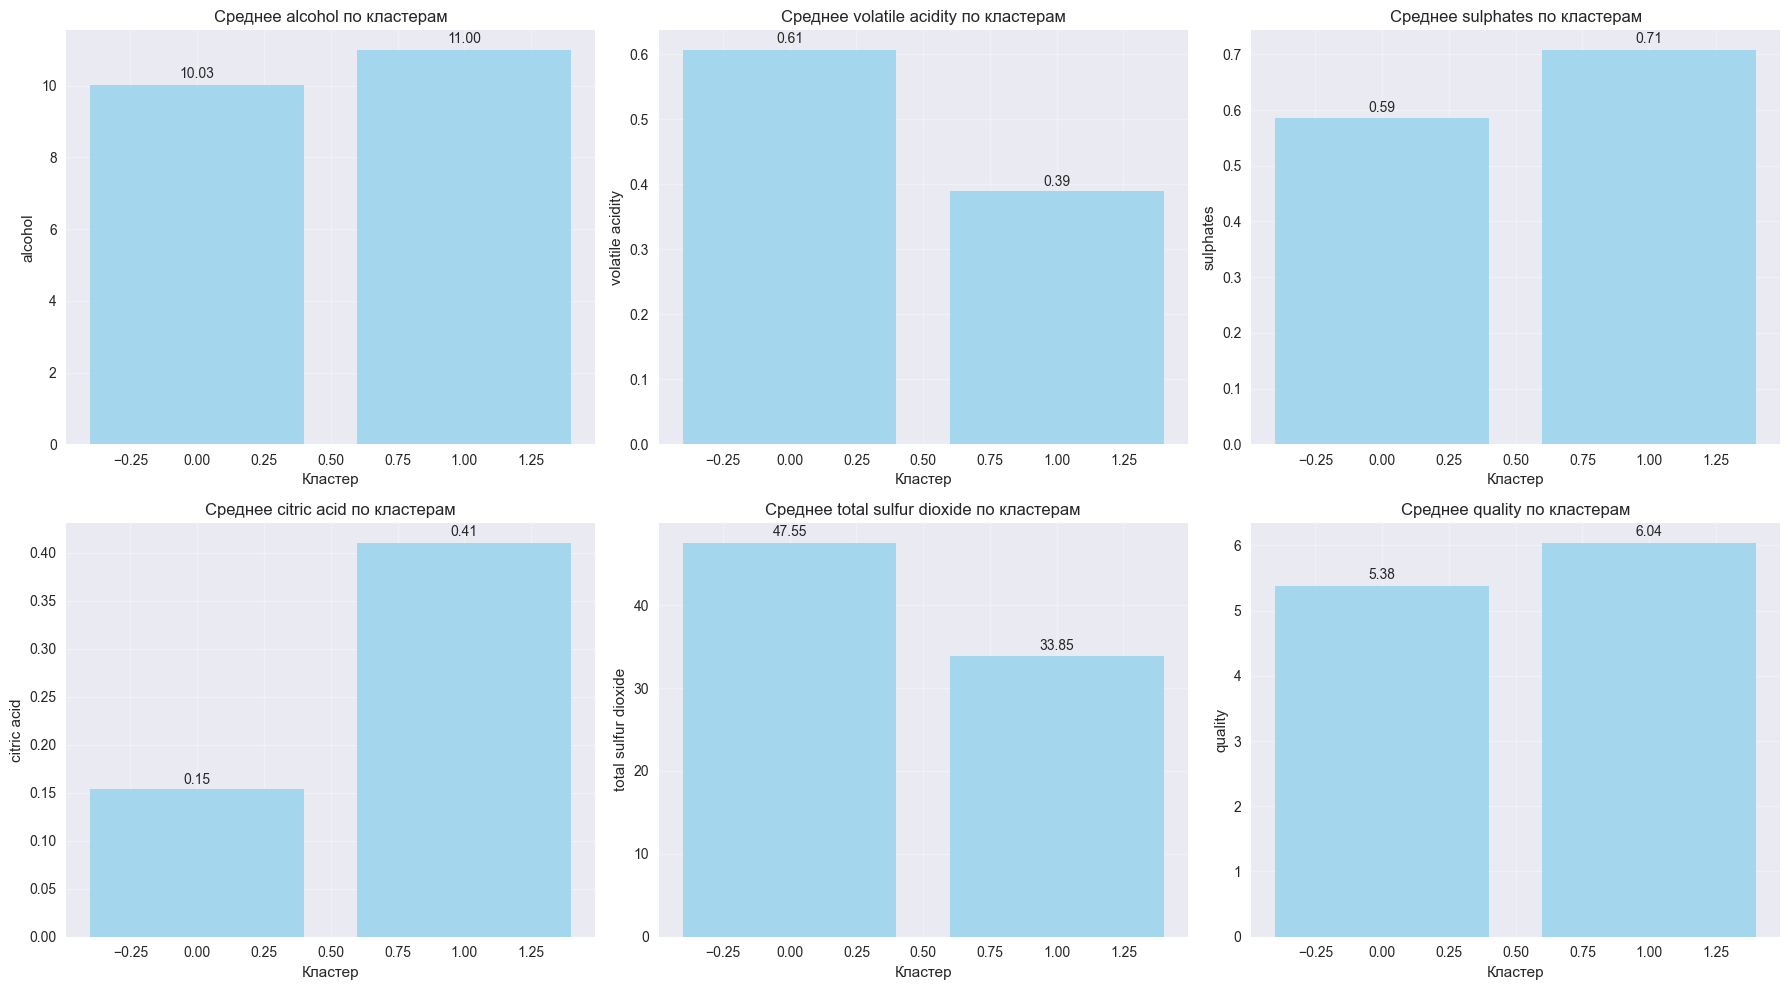

In [3]:
print("\n4. КЛАСТЕРИЗАЦИЯ МЕТОДОМ K-MEANS")
print("="*50)

X = wine_data_no_outliers[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ:")

wcss = []  # Within-Cluster Sum of Square
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    if k > 1:  
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('WCSS (Within-Cluster Sum of Square)')
ax1.set_title('Метод локтя для определения оптимального K')
ax1.grid(True, alpha=0.3)

ax2.plot(range(2, 10), silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score для разных значений K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Оптимальное количество кластеров: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

wine_data_no_outliers['cluster'] = clusters

print(f"\nРАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:")
cluster_counts = wine_data_no_outliers['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"Кластер {cluster}: {count} образцов ({count/len(wine_data_no_outliers)*100:.1f}%)")

# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ:")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter1 = axes[0,0].scatter(wine_data_no_outliers['alcohol'], 
                            wine_data_no_outliers['volatile acidity'], 
                            c=wine_data_no_outliers['cluster'], cmap='tab10', alpha=0.7)
axes[0,0].set_xlabel('Alcohol (%)')
axes[0,0].set_ylabel('Volatile Acidity')
axes[0,0].set_title('Кластеры: Alcohol vs Volatile Acidity')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0,0])

scatter2 = axes[0,1].scatter(wine_data_no_outliers['sulphates'], 
                            wine_data_no_outliers['citric acid'], 
                            c=wine_data_no_outliers['cluster'], cmap='tab10', alpha=0.7)
axes[0,1].set_xlabel('Sulphates')
axes[0,1].set_ylabel('Citric Acid')
axes[0,1].set_title('Кластеры: Sulphates vs Citric Acid')
axes[0,1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0,1])

scatter3 = axes[1,0].scatter(wine_data_no_outliers['alcohol'], 
                            wine_data_no_outliers['sulphates'], 
                            c=wine_data_no_outliers['cluster'], cmap='tab10', alpha=0.7)
axes[1,0].set_xlabel('Alcohol (%)')
axes[1,0].set_ylabel('Sulphates')
axes[1,0].set_title('Кластеры: Alcohol vs Sulphates')
axes[1,0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1,0])

cluster_quality = wine_data_no_outliers.groupby('cluster')['quality'].mean()
axes[1,1].bar(cluster_quality.index, cluster_quality.values, color='lightgreen', alpha=0.7)
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Среднее качество')
axes[1,1].set_title('Среднее качество вина по кластерам')
axes[1,1].grid(True, alpha=0.3)

for i, v in enumerate(cluster_quality.values):
    axes[1,1].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nАНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ:")
print("="*50)

cluster_analysis = wine_data_no_outliers.groupby('cluster')[features_for_clustering + ['quality']].mean()

print("СРЕДНИЕ ЗНАЧЕНИЯ ХАРАКТЕРИСТИК ПО КЛАСТЕРАМ:")
display(cluster_analysis.round(3))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = features_for_clustering + ['quality']

for i, feature in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    cluster_means = wine_data_no_outliers.groupby('cluster')[feature].mean()
    axes[row, col].bar(cluster_means.index, cluster_means.values, color='skyblue', alpha=0.7)
    axes[row, col].set_title(f'Среднее {feature} по кластерам')
    axes[row, col].set_xlabel('Кластер')
    axes[row, col].set_ylabel(feature)
    axes[row, col].grid(True, alpha=0.3)
    
    for j, v in enumerate(cluster_means.values):
        axes[row, col].text(j, v + 0.01 * v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



In [4]:
print("\n5. ВЫВОДЫ И ЗАКЛЮЧЕНИЯ")
print("="*50)

conclusions = """
ОСНОВНЫЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ:

1. ПРЕДОБРАБОТКА ДАННЫХ:
   • Добавлены новые атрибуты: acidity_profile и sweetness_category
   • Удалены дубликаты и выбросы 
   • Данные масштабированы для улучшения качества кластеризации

2. ВИЗУАЛЬНЫЙ АНАЛИЗ:
   • На scatter-графиках видны естественные группировки данных
   • Наиболее выраженные кластеры наблюдаются в пространствах:
        - Alcohol vs Volatile Acidity
        - Alcohol vs Sulphates

3. КЛАСТЕРИЗАЦИЯ K-MEANS:
   • Оптимальное количество кластеров определено методом локтя и silhouette score
   • Алгоритм успешно выделил различные группы вин
   • Кластеры имеют различия в химическом составе и качестве

4. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:
   • Высококачественные кластеры: характеризуются высоким содержанием алкоголя, 
     сульфатов и лимонной кислоты, низкой летучей кислотностью
   • Низкокачественные кластеры: противоположные характеристики
   • Кластеры демонстрируют различные "винные профили"

5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   • Может использоваться для сегментации вин по химическому составу
   • Помогает идентифицировать характеристики, влияющие на качество
   • Полезно для контроля качества и оптимизации производства

МЕТОДОЛОГИЧЕСКИЕ ВЫВОДЫ:
• K-means эффективен для сегментации вин по химическим параметрам
• Предобработка данных критически важна для качества кластеризации
• Визуализация помогает интерпретировать и валидировать результаты
"""

print(conclusions)


5. ВЫВОДЫ И ЗАКЛЮЧЕНИЯ

ОСНОВНЫЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ:

1. ПРЕДОБРАБОТКА ДАННЫХ:
   • Добавлены новые атрибуты: acidity_profile и sweetness_category
   • Удалены дубликаты и выбросы 
   • Данные масштабированы для улучшения качества кластеризации

2. ВИЗУАЛЬНЫЙ АНАЛИЗ:
   • На scatter-графиках видны естественные группировки данных
   • Наиболее выраженные кластеры наблюдаются в пространствах:
        - Alcohol vs Volatile Acidity
        - Alcohol vs Sulphates

3. КЛАСТЕРИЗАЦИЯ K-MEANS:
   • Оптимальное количество кластеров определено методом локтя и silhouette score
   • Алгоритм успешно выделил различные группы вин
   • Кластеры имеют различия в химическом составе и качестве

4. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:
   • Высококачественные кластеры: характеризуются высоким содержанием алкоголя, 
     сульфатов и лимонной кислоты, низкой летучей кислотностью
   • Низкокачественные кластеры: противоположные характеристики
   • Кластеры демонстрируют различные "винные профили"

5. ПРАКТИЧЕ